Ejercicio 1: Funciones Base de Bernstein

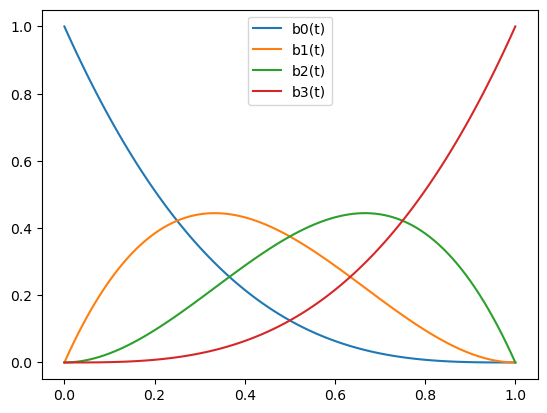

True


In [5]:
# Inciso (a)

import math
import numpy as np
import matplotlib.pyplot as plt
import random

def bernstein3(t):
    matriz = np.zeros((4, len(t)))
    for i in range(len(t)):
        x = t[i]
        b0 = (1-x)**3
        b1 = 3*((1-x)**2)*x
        b2 = 3*(1-x)*(x**2)
        b3 = x**3
        matriz[0][i] = b0
        matriz[1][i] = b1
        matriz[2][i] = b2
        matriz[3][i] = b3

    return matriz

# Inciso (b)

def graficar():
    
    t = np.array([])
    for x in range(101):
        t = np.append(t, x / 100)

    matriz = bernstein3(t)

    plt.plot(t, matriz[0], label = "b0(t)")
    plt.plot(t, matriz[1],label = "b1(t)")
    plt.plot(t, matriz[2],label = "b2(t)")
    plt.plot(t, matriz[3],label = "b3(t)")
    plt.legend()

    plt.show()    


graficar()

# Inciso (c)

def verificacion(matriz):
    
    cumple = True
    for i in range(len(matriz[0])):
        suma = matriz[0][i] + matriz[1][i] + matriz[2][i] + matriz[3][i]
        cumple = np.isclose(suma, 1)
    return cumple

t = np.array([])
for x in range(101):
    t = np.append(t, x / 100)
print(verificacion(bernstein3(t)))


Inciso (d)

Como los coeficientes de la curva de Bezier suman 1, cada punto de control de la curva tiene un "peso" asignadoque funciona como un promedio ponderado entre los puntos. Cada caoeficiente indica cuanto influye cada punto de control en la posición de la curva. Es por esto que la curva queda contenida entre los puntos de control. 

Ejercicio 2

[[1.00000e+00 9.70299e-01 9.41192e-01 9.12673e-01 8.84736e-01 8.57375e-01
  8.30584e-01 8.04357e-01 7.78688e-01 7.53571e-01 7.29000e-01 7.04969e-01
  6.81472e-01 6.58503e-01 6.36056e-01 6.14125e-01 5.92704e-01 5.71787e-01
  5.51368e-01 5.31441e-01 5.12000e-01 4.93039e-01 4.74552e-01 4.56533e-01
  4.38976e-01 4.21875e-01 4.05224e-01 3.89017e-01 3.73248e-01 3.57911e-01
  3.43000e-01 3.28509e-01 3.14432e-01 3.00763e-01 2.87496e-01 2.74625e-01
  2.62144e-01 2.50047e-01 2.38328e-01 2.26981e-01 2.16000e-01 2.05379e-01
  1.95112e-01 1.85193e-01 1.75616e-01 1.66375e-01 1.57464e-01 1.48877e-01
  1.40608e-01 1.32651e-01 1.25000e-01 1.17649e-01 1.10592e-01 1.03823e-01
  9.73360e-02 9.11250e-02 8.51840e-02 7.95070e-02 7.40880e-02 6.89210e-02
  6.40000e-02 5.93190e-02 5.48720e-02 5.06530e-02 4.66560e-02 4.28750e-02
  3.93040e-02 3.59370e-02 3.27680e-02 2.97910e-02 2.70000e-02 2.43890e-02
  2.19520e-02 1.96830e-02 1.75760e-02 1.56250e-02 1.38240e-02 1.21670e-02
  1.06480e-02 9.26100e-03 8.00000e-03 

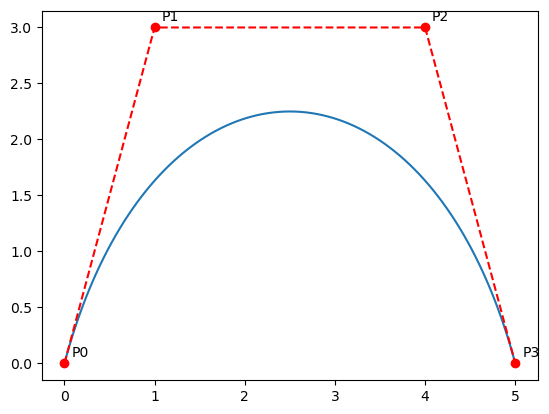

In [26]:

import math
import numpy as np
import matplotlib.pyplot as plt
import random

np.random.seed(42)

# Inciso (a)

t = []
for x in range(101):
    t.append(x / 100)

matriz_A = bernstein3(t)

print(matriz_A)

# Inciso (b)

def P(P1,P2,P3,P4):

    filas_puntos = []
    filas_puntos.append(P1)
    filas_puntos.append(P2)
    filas_puntos.append(P3)
    filas_puntos.append(P4)
    matriz_P = np.array(filas_puntos)
    return matriz_P

matriz_P = P([0,0],[1,3],[4,3],[5,0])
print(matriz_P)

# Inciso (c)

def C(matriz_A, matriz_P):

    filas = []
    for i in range(len(matriz_A[0])):
        filas.append(matriz_A[0][i] * matriz_P[0] + matriz_A[1][i] * matriz_P[1] + matriz_A[2][i] * matriz_P[2] + matriz_A[3][i] * matriz_P[3])

    matriz_C = np.array(filas)
    return matriz_C

matriz_C = C(matriz_A, matriz_P)
print(matriz_C)

# Inciso (d)

def graficar_matriz(matriz_puntos, puntos_control):

    xs = []
    ys = []
    for punto in matriz_puntos:
        xs.append(punto[0])
        ys.append(punto[1])
        
    plt.plot(xs,ys)

    poligonal_control_x = [puntos_control[0][0], puntos_control[1][0], puntos_control[2][0], puntos_control[3][0]]
    poligonal_control_y = [puntos_control[0][1], puntos_control[1][1], puntos_control[2][1], puntos_control[3][1]]

    # Poligonal de control
    plt.plot(poligonal_control_x, poligonal_control_y, 'r--o')

    # Puntos de control (etiquetas)
    for i, (x, y) in enumerate(puntos_control): 
        plt.annotate(f"P{i}", (x, y), textcoords="offset points", xytext=(5, 5))

    #plt.show()
    

graficar_matriz(matriz_C, matriz_P)

Inciso (e)

Matriz A: dimension 100x4

Esta matriz representa los coeficientes del polinomio de Bernstein evaluados en 100 valores de t entre 0 y 1 (equiespaciados). Cada columna representa un coeficiente de Bernstein (b0, b1, b2 y b3) y cada fila es una evaluacion de los cuatro coeficientes para cierto valor t. 

Matriz P: dimension 4x2

Esta matriz representa los 4 puntos de control (uno por fila) de la curva de Bezier. Cada fila contiene 2 coordenadas para dicho punto. 

Matriz C: dimension 100x2

Esta matriz representa 100 puntos de la curva de Bezier (uno pr fila, donde cada fila contiene 2 coordenadas para dicho punto). 

Ejercicio 3

[[0.       0.      ]
 [0.030596 0.0891  ]
 [0.062368 0.1764  ]
 [0.095292 0.2619  ]
 [0.129344 0.3456  ]
 [0.1645   0.4275  ]
 [0.200736 0.5076  ]
 [0.238028 0.5859  ]
 [0.276352 0.6624  ]
 [0.315684 0.7371  ]
 [0.356    0.81    ]
 [0.397276 0.8811  ]
 [0.439488 0.9504  ]
 [0.482612 1.0179  ]
 [0.526624 1.0836  ]
 [0.5715   1.1475  ]
 [0.617216 1.2096  ]
 [0.663748 1.2699  ]
 [0.711072 1.3284  ]
 [0.759164 1.3851  ]
 [0.808    1.44    ]
 [0.857556 1.4931  ]
 [0.907808 1.5444  ]
 [0.958732 1.5939  ]
 [1.010304 1.6416  ]
 [1.0625   1.6875  ]
 [1.115296 1.7316  ]
 [1.168668 1.7739  ]
 [1.222592 1.8144  ]
 [1.277044 1.8531  ]
 [1.332    1.89    ]
 [1.387436 1.9251  ]
 [1.443328 1.9584  ]
 [1.499652 1.9899  ]
 [1.556384 2.0196  ]
 [1.6135   2.0475  ]
 [1.670976 2.0736  ]
 [1.728788 2.0979  ]
 [1.786912 2.1204  ]
 [1.845324 2.1411  ]
 [1.904    2.16    ]
 [1.962916 2.1771  ]
 [2.022048 2.1924  ]
 [2.081372 2.2059  ]
 [2.140864 2.2176  ]
 [2.2005   2.2275  ]
 [2.260256 2.2356  ]
 [2.320108 2.

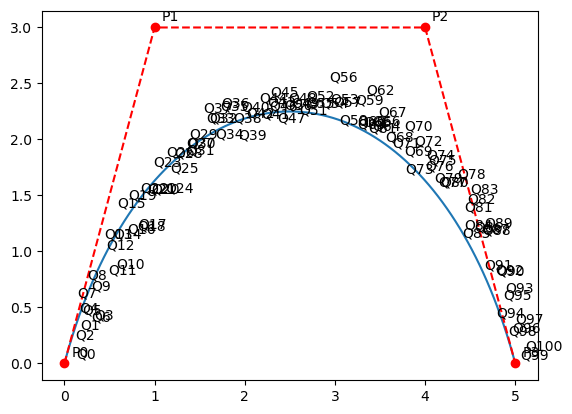

In [ ]:


# Inciso (a)

t = []
for x in range(30):
    t.append(x / 29)


# Inciso (b)

matriz_A2 = bernstein3(t)

matriz_P2 = P([0,0], [1,3], [4,3], [5,0])
matriz_C2 = C(matriz_A2, matriz_P2)

print(matriz_C)

# Inciso (c)

def ruido_gaussiano(matriz_C):
    vector_ruidos = []
    matriz_ruido = matriz_C.copy()
    for i in range(len(matriz_C)):
        ruido_x = np.random.normal(0, 0.1)
        ruido_y = np.random.normal(0, 0.1)
        vector_ruidos.append([ruido_x,ruido_y])
        matriz_ruido[i] = [matriz_C[i][0]+ruido_x, matriz_C[i][1]+ ruido_y] 
    return matriz_ruido

matriz_ruido = ruido_gaussiano(matriz_C)
print(matriz_ruido)

# Inciso (d)

graficar_matriz(matriz_C, matriz_P)
for i, (x, y) in enumerate(matriz_ruido): 
        plt.annotate(f"Q{i}", (x, y), textcoords="offset points", xytext=(5, 5))


